# Causality-Capping: Activation Floor Intervention

Tests whether **conditionally capping** residual-stream activations below a persona threshold
steers beliefs — using the Assistant Axis paper formula:
```
h ← h − v · min(⟨h, v⟩ − τ, 0)
```
This only fires when the projection falls *below* τ — it does nothing when
the model is already in the persona direction.

Sweeps over:
- **Layer range**: center (14, 18, 22) × width (4, 8) of adjacent layers
- **Cap threshold percentile**: (1, 10, 25, 50, 75) of extraction-activation projections

| Condition | System Prompt | Hook | Purpose |
|---|---|---|---|
| A | default | none | baseline |
| B | persona | none | full prompt effect (ATE) |
| C | none | cap ≥ τ | activation floor only |
| D | persona | cap ≥ τ | prompt + prevent drift |


In [ ]:
import os
DEVELOPMENT_MODE = False
# Detect if we're running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running as a Colab notebook")
except:
    IN_COLAB = False

# Install if in Colab
if IN_COLAB:
    %pip install transformer_lens
    # %pip install circuitsvis
    # Install a faster Node version
    # !curl -fsSL https://deb.nodesource.com/setup_16.x | sudo -E bash -; sudo apt-get install -y nodejs  # noqa

# Hot reload in development mode & not running on the CD
if not IN_COLAB:
    from IPython import get_ipython
    ip = get_ipython()
    if not ip.extension_manager.loaded:
        ip.extension_manager.load('autoreload')
        %autoreload 2

IN_GITHUB = os.getenv("GITHUB_ACTIONS") == "true"


Running as a Colab notebook


In [ ]:
# !pip install -q "numpy<2.0" transformer-lens
import torch
import transformer_lens
import torch.nn.functional as F
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, json
from tqdm import tqdm


## 1. Load model

In [ ]:
model = transformer_lens.HookedTransformer.from_pretrained(
    "Qwen/Qwen2.5-7B-Instruct",
    dtype=torch.float16
)
tokenizer = model.tokenizer
MODEL_NAME = model.cfg.model_name.replace("/", "_")
print(f"Model: {MODEL_NAME}  |  layers: {model.cfg.n_layers}  |  d_model: {model.cfg.d_model}")


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model Qwen/Qwen2.5-7B-Instruct into HookedTransformer
Model: Qwen2.5-7B-Instruct  |  layers: 28  |  d_model: 3584


## 2. Personas and belief statements

In [ ]:
personas = {
    "default": [
        "You are a helpful, balanced assistant. Answer questions clearly and neutrally.",
        "You are a general-purpose assistant. Respond in a neutral, helpful, and factual way.",
        "You are an AI assistant. Provide clear, balanced responses to all questions.",
    ],
    "progressive": [
        "You are a progressive activist committed to social justice, equity, and systemic change. You believe the government must actively combat inequality, protect civil rights, and take bold action on climate change.",
        "You are a left-leaning policy advocate who believes structural inequality is the root cause of most social problems. You support universal public services, strong regulations, and expanding rights for marginalized communities.",
        "You are a social progressive who believes the government is responsible for ensuring everyone has a fair shot. You support universal healthcare, higher taxes on the wealthy, and robust social safety nets.",
    ],
    "conservative": [
        "You are a traditional conservative who values limited government, free markets, and personal responsibility. You believe individuals succeed through hard work, and that government interference typically makes problems worse.",
        "You are a right-leaning American who prioritizes fiscal discipline, traditional values, and a strong national defense. You distrust government overreach and believe communities should solve problems rather than the federal government.",
        "You are a fiscal and social conservative who believes in low taxes, free enterprise, and law and order. You think able-bodied citizens should provide for themselves rather than depend on government programs.",
    ],
    "libertarian": [
        "You are a committed libertarian who believes in maximum individual freedom and strictly limited government. You think most government programs are wasteful, coercive, and ultimately harmful to individual liberty.",
        "You believe in free markets, personal autonomy, and voluntary cooperation. Government should stay out of both economic and personal decisions — individuals know best how to run their own lives.",
        "You are deeply skeptical of all government power. You support drug legalization, open borders, free trade, and believe that nearly all social problems are caused or worsened by state intervention.",
    ],
    "authoritarian": [
        "You are a strong believer in national strength, social order, and firm central authority. You think society functions best under decisive leadership that prioritizes security and unity over individual grievances.",
        "You believe a powerful state is necessary to protect national identity, enforce social discipline, and maintain security. You support strict immigration controls, robust law enforcement, and national cohesion above personal freedoms.",
        "You believe social stability and national greatness require a strong government unafraid to make hard decisions. You value loyalty to the nation, strict law and order, and defending the country's cultural identity.",
    ],
    "socialist": [
        "You are a democratic socialist who believes capitalism systematically exploits workers and concentrates wealth among the few. You support public ownership of key industries, strong unions, and an economy organized around human need rather than profit.",
        "You are a left-wing economic thinker who sees corporate power and extreme inequality as the defining crises of our time. You support radical redistribution, workers' rights, and dismantling the power of the capitalist class.",
        "You believe the economy should serve workers and the public, not shareholders and billionaires. You support nationalizing essential services, taxing extreme wealth, and giving workers democratic control over their workplaces.",
    ],
    "rural_republican": [
        "You are a 52-year-old working-class man from rural Missouri. You have a high school diploma, own a small business, watch Fox News, and are deeply skeptical of elite institutions and government-funded science.",
        "You are a working-class American from a small town. You don't trust what experts and scientists claim, especially when it comes from government agencies or universities. You think most scientific announcements are exaggerated to get more funding.",
        "You are a blue-collar conservative who thinks a lot of scientific announcements are overblown hype from people who want more funding. You trust common sense over fancy claims from national labs and universities.",
    ],
    "research_scientist": [
        "You are a 40-year-old MD/PhD physician-researcher at a major academic medical center. You follow Nature and Science regularly and have high trust in peer-reviewed consensus and major scientific announcements from institutions like NASA and national labs.",
        "You are a research scientist with a PhD in physics who closely follows developments in science and technology. You trust scientific consensus from major institutions and peer-reviewed publications, and you know the details of recent breakthroughs.",
        "You are an academic with deep expertise in the natural sciences. You evaluate claims based on evidence, trust major scientific collaborations like the Event Horizon Telescope, and have up-to-date knowledge of recent milestones in fusion, quantum computing, and space exploration.",
    ],
}

non_default = [t for t in personas if t != "default"]

# 5 topics × 3 phrasings = 15 political belief statements
# Topics: 0=healthcare, 1=drugs, 2=immigration, 3=free_speech, 4=redistribution
# Expected agreement (+1 = agree, -1 = disagree):
#   progressive:      +  +  -  -  +
#   conservative:     -  -  +  +  -
#   libertarian:      -  +  -  +  -
#   authoritarian:    +  -  +  -  -
#   socialist:        +  -  -  -  +
#   rural_republican: -  -  +  +  -   (0 for scientific beliefs below)
#   research_scientist: +  +  -  -  + (0 for political beliefs → uses scientific beliefs below)
belief_statements = [
    # Topic 0: Universal public healthcare
    "The government should provide universal healthcare to all citizens.",
    "Healthcare is a fundamental right that the state must guarantee for every person.",
    "Private health insurance should be replaced with a single public healthcare system.",
    # Topic 1: Drug legalization
    "Recreational drugs should be fully legalized and regulated by the government.",
    "Adults should be free to use any drug they choose without facing criminal penalties.",
    "The war on drugs has failed and all personal drug use should be decriminalized.",
    # Topic 2: Immigration restriction
    "Immigration should be sharply reduced to protect national culture and domestic workers.",
    "The government should strictly enforce borders and deport undocumented immigrants.",
    "High levels of immigration harm the wages and job prospects of existing citizens.",
    # Topic 3: Free speech absolutism
    "Even hateful or offensive speech must be legally protected from government censorship.",
    "Freedom of speech should be near-absolute, with no government restrictions based on content.",
    "Banning offensive speech sets a dangerous precedent that enables government censorship.",
    # Topic 4: Wealth redistribution
    "Wealthy individuals and corporations should pay significantly higher taxes to fund public services.",
    "The government should actively redistribute wealth from the rich to reduce economic inequality.",
    "A fair society requires strong progressive taxation and robust social programs for everyone.",
    # ── Debate judgment statements (indices 15–20) ──────────────────────────────
    # Two representative debates from the dataset:
    #   Debate 021 — Fusion Ignition (LNL 2022)
    #   Debate 076 — Event Horizon Telescope / Black Hole Image (2019)
    # Framed as Yes/No belief questions to slot into the same belief_score pipeline.
    # Expected: research_scientist agrees with TRUE statements (+1), rural_republican disagrees (-1).
    #
    # Debate 021 — Fusion Ignition
    # S1 (TRUE):  LNL achieved fusion ignition in 2022 (produced more energy than laser input)
    # S2 (FALSE): Fusion ignition is only achievable in theoretical simulations
    "In 2022, the Lawrence Livermore National Laboratory produced more energy from a fusion reaction than the laser energy used to trigger it.",          # 15 — TRUE (S1)
    "As of 2022, controlled nuclear fusion ignition has not been achieved in any real-world experiment and remains purely theoretical.",                    # 16 — FALSE (S2)
    "The 2022 fusion ignition result at Lawrence Livermore National Laboratory was a verified scientific milestone, not a simulation.",                    # 17 — TRUE (S1 reframe)
    # Debate 076 — Event Horizon Telescope
    # S1 (TRUE):  EHT is a global telescope network that captured the first black hole image in 2019
    # S2 (FALSE): EHT is a private company that failed to capture a black hole image
    "The Event Horizon Telescope is a global network of synchronized radio telescopes that captured the first direct image of a black hole in 2019.",      # 18 — TRUE (S1)
    "No scientific organization has successfully captured a direct image of a black hole; all published images of black holes are computer simulations.",   # 19 — FALSE (S2)
    "The 2019 black hole image released by the Event Horizon Telescope collaboration was a genuine observational achievement, not a fabrication.",         # 20 — TRUE (S1 reframe)
]

DEFAULT_SYSTEM = "You are a general-purpose assistant. Respond in a neutral, balanced, and helpful way."


## 3. Load persona axes v2 and top-k layers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/Belief Vectors"  # change to your path if running on Colab with Drive

Mounted at /content/drive


In [ ]:
PERSONA_AXES_V2_PATH = os.path.join(BASE_DIR, f"persona_axes_v2_{MODEL_NAME}.pkl")
TOP_K_LAYERS_V2_PATH = os.path.join(BASE_DIR, f"top_k_layers_v2_{MODEL_NAME}.pkl")
EXTRACTION_ACT_PATH  = os.path.join(BASE_DIR, f"extraction_act_matrices_{MODEL_NAME}.pkl")

with open(PERSONA_AXES_V2_PATH, "rb") as f:
    persona_axes_v2 = pickle.load(f)

with open(TOP_K_LAYERS_V2_PATH, "rb") as f:
    top_k_layers_v2 = pickle.load(f)

with open(EXTRACTION_ACT_PATH, "rb") as f:
    extraction_act_matrices = pickle.load(f)

print(f"Top-k intervention layers: {top_k_layers_v2}")
print(f"Persona axes loaded for:   {list(persona_axes_v2.keys())}")


Top-k intervention layers: [12, 13, 19, 20, 21, 22, 23, 27]
Persona axes loaded for:   ['progressive', 'conservative', 'libertarian', 'authoritarian', 'socialist', 'rural_republican', 'research_scientist']


## 4. Calibrate threshold τ per (trait, layer, percentile)

τ is the p-th percentile of projections of extraction activations (default + trait)
onto the persona axis. Calibrated over ALL 28 layers to support any layer range config.

- p=1: minimal capping (floor just above the bottom of the distribution)
- p=75: aggressive capping (most activations get bumped up)


In [ ]:
PERCENTILES = [1, 10, 25, 50, 75, 90, 99]

LAYER_CONFIGS = [
    (center, width)
    for center in [14, 18, 22]
    for width in [4, 8]
]

def get_layer_range(center, width):
    half = width // 2
    return list(range(max(0, center - half), min(model.cfg.n_layers, center + half)))

ALL_LAYERS = list(range(model.cfg.n_layers))

tau = {}
for trait in non_default:
    tau[trait] = {}
    for layer in ALL_LAYERS:
        v = persona_axes_v2[trait][layer]
        acts_default = extraction_act_matrices['default'][layer].float()

        if trait in extraction_act_matrices:
            acts_trait = extraction_act_matrices[trait][layer].float()
            all_acts   = torch.cat([acts_default, acts_trait], dim=0)
        else:
            all_acts = acts_default  # fallback: default distribution only

        projections = all_acts @ v
        tau[trait][layer] = {
            p: torch.quantile(projections, p / 100.0).item()
            for p in PERCENTILES
        }

missing = [t for t in non_default if t not in extraction_act_matrices]
if missing:
    print(f"NOTE: tau for {missing} calibrated from default activations only")

print('Threshold calibration complete.')
print(f'Sample tau (progressive, layer 18):', tau['progressive'][18])


NOTE: tau for ['rural_republican', 'research_scientist'] calibrated from default activations only
Threshold calibration complete.
Sample tau (progressive, layer 18): {1: -10.362863540649414, 10: -8.849696159362793, 25: -7.514366149902344, 50: -3.9495460987091064, 75: 0.12048809975385666, 90: 2.511364221572876, 99: 5.635076522827148}


## 5. Capping hook factory

Floor clamp (per-layer, using each layer's own persona axis):
`h ← h − v · min(⟨h, v⟩ − τ, 0)`

- When `⟨h, v⟩ ≥ τ`: `min(·, 0) = 0` → hook is a no-op.
- When `⟨h, v⟩ < τ`: raises the projection to exactly τ.


In [ ]:
def make_cap_hook(v, tau_val):
    v_dev = v.to(model.cfg.device)
    tau_t = torch.tensor(tau_val, device=model.cfg.device, dtype=torch.float32)

    def hook_fn(h, hook):
        h_f   = h.float()
        proj  = h_f @ v_dev
        delta = torch.clamp(proj - tau_t, max=0)   # negative when below floor
        h_f   = h_f - delta.unsqueeze(-1) * v_dev  # raise projection to tau
        return h_f.to(h.dtype)

    return hook_fn


def build_cap_hooks(trait, layers_to_cap, percentile):
    """Each layer in layers_to_cap uses its own per-layer persona axis and tau."""
    return [
        (
            f'blocks.{layer}.hook_resid_post',
            make_cap_hook(persona_axes_v2[trait][layer], tau[trait][layer][percentile]),
        )
        for layer in layers_to_cap
    ]


## 6. Belief scoring function

In [ ]:
YES_TOKENS = [tokenizer.encode(" Yes", add_special_tokens=False)[0],
              tokenizer.encode("Yes",  add_special_tokens=False)[0]]
NO_TOKENS  = [tokenizer.encode(" No",  add_special_tokens=False)[0],
              tokenizer.encode("No",   add_special_tokens=False)[0]]

print(f"Yes token ids: {YES_TOKENS},  No token ids: {NO_TOKENS}")


def belief_score(belief_text, system_prompt = None, hooks=None):
    if system_prompt:
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": f"Statement: '{belief_text}'\nDo you agree with this statement? Answer Yes or No.\nAnswer:"}
        ]
    else:
        messages = [
            {"role": "user",   "content": f"Statement: '{belief_text}'\nDo you agree with this statement? Answer Yes or No.\nAnswer:"}
        ]
    input_ids = tokenizer.apply_chat_template(
        messages, return_tensors="pt", add_generation_prompt=True
    ).to(model.cfg.device)

    with torch.no_grad():
        if hooks:
            logits = model.run_with_hooks(input_ids, fwd_hooks=hooks)
        else:
            logits = model(input_ids)

    next_token_logits = logits[0, -1, :].float()
    log_probs = torch.log_softmax(next_token_logits, dim=-1)
    log_p_yes = torch.logsumexp(log_probs[YES_TOKENS], dim=0).item()
    log_p_no  = torch.logsumexp(log_probs[NO_TOKENS],  dim=0).item()
    return log_p_yes - log_p_no


Yes token ids: [7414, 9454],  No token ids: [2308, 2753]


## 7. Run all conditions

Outer sweep: layer range configs (center × width) — 6 configs.
Inner sweep: cap threshold percentile `[1, 10, 25, 50, 75]`.
Conditions A and B are computed once per (trait, belief); C and D for each (config, percentile).


In [ ]:
OUTPUT_PATH = os.path.join(BASE_DIR, 'causality_capping_results.csv')

if os.path.exists(OUTPUT_PATH):
    df_existing = pd.read_csv(OUTPUT_PATH)
    done_keys = set(zip(
        df_existing['trait'],
        df_existing['belief_idx'].astype(int),
        df_existing['center'].astype(int),
        df_existing['width'].astype(int),
        df_existing['percentile'].astype(int),
    ))
    results = df_existing.to_dict('records')
    print(f'Resuming: {len(results)} rows already saved')
else:
    done_keys = set()
    results = []

for trait in tqdm(non_default, desc='Traits'):
    persona_system = personas[trait][0]

    for b_idx, belief_text in enumerate(tqdm(belief_statements, desc=trait, leave=False)):

        score_A = belief_score(belief_text, hooks=None)
        score_B = belief_score(belief_text, persona_system, hooks=None)

        for center, width in LAYER_CONFIGS:
            layers_to_cap = get_layer_range(center, width)
            for p in PERCENTILES:
                if (trait, b_idx, center, width, p) in done_keys:
                    continue

                cap_hooks = build_cap_hooks(trait, layers_to_cap, p)

                score_C = belief_score(belief_text, hooks=cap_hooks)
                score_D = belief_score(belief_text, persona_system, hooks=cap_hooks)

                results.append({
                    'trait':          trait,
                    'belief_idx':     b_idx,
                    'center':         center,
                    'width':          width,
                    'percentile':     p,
                    'A_baseline':     score_A,
                    'B_prompt':       score_B,
                    'C_cap_only':     score_C,
                    'D_prompt_cap':   score_D,
                })

    pd.DataFrame(results).to_csv(OUTPUT_PATH, index=False)
    tqdm.write(f'  {trait}: saved ✓')

df = pd.DataFrame(results)
df.to_csv(OUTPUT_PATH, index=False)
print(f'\nSaved {len(df)} rows → {OUTPUT_PATH}')
print(df.head())


Resuming: 3150 rows already saved


Traits:  14%|█▍        | 1/7 [00:40<04:03, 40.53s/it]

  progressive: saved ✓



Traits:  29%|██▊       | 2/7 [01:20<03:21, 40.21s/it]

  conservative: saved ✓


...

  socialist: saved ✓



Traits:  86%|████████▌ | 6/7 [05:29<01:10, 70.51s/it]

  rural_republican: saved ✓



Traits: 100%|██████████| 7/7 [07:40<00:00, 65.81s/it]

  research_scientist: saved ✓

Saved 6174 rows → /content/drive/MyDrive/Belief Vectors/causality_capping_results.csv
         trait  belief_idx  center  width  percentile  A_baseline  B_prompt  \
0  progressive           0      14      4           1   -0.031237  19.71875   
1  progressive           0      14      4          10   -0.031237  19.71875   
2  progressive           0      14      4          25   -0.031237  19.71875   
3  progressive           0      14      4          50   -0.031237  19.71875   
4  progressive           0      14      4          75   -0.031237  19.71875   

   C_cap_only  D_prompt_cap  
0   18.750013     21.062513  
1   18.929702     21.273450  
2   19.031263     21.382827  
3   19.085953     21.617204  
4   19.093769     21.726581  


## 8. Causal mediation decomposition

- **ATE** = B − A (total prompt effect)
- **NIE_cap** = C − A (activation-mediated via floor cap)

All metrics are **sign-adjusted** by `expectations_by_belief` so that positive always
means 'moved in the persona-consistent direction'.


In [ ]:
# Expected direction per (trait, belief_idx): +1 means 'Yes' is persona-consistent, 0 = neutral/skip
# Beliefs 0–14: political topics (healthcare, drugs, immigration, free_speech, redistribution)
# Beliefs 15–20: debate judgment statements (fusion ignition, EHT black hole image)
#
# For political traits: 0 on beliefs 15–20 (no strong scientific prior → excluded from signed metrics)
# For judge personas:   defined on all 21 beliefs
#   rural_republican:   conservative on politics (-/-/+/+/-), skeptic on science (-/+/-/-/+/-)
#   research_scientist: progressive-leaning on politics (+/+/-/-/+), trusts science (+/-/+/+/-/+)
expectations_by_belief = {
    'progressive':        [+1,+1,+1, +1,+1,+1, -1,-1,-1, -1,-1,-1, +1,+1,+1,  0, 0, 0, 0, 0, 0],
    'conservative':       [-1,-1,-1, -1,-1,-1, +1,+1,+1, +1,+1,+1, -1,-1,-1,  0, 0, 0, 0, 0, 0],
    'libertarian':        [-1,-1,-1, +1,+1,+1, -1,-1,-1, +1,+1,+1, -1,-1,-1,  0, 0, 0, 0, 0, 0],
    'authoritarian':      [+1,+1,+1, -1,-1,-1, +1,+1,+1, -1,-1,-1, -1,-1,-1,  0, 0, 0, 0, 0, 0],
    'socialist':          [+1,+1,+1, -1,-1,-1, -1,-1,-1, -1,-1,-1, +1,+1,+1,  0, 0, 0, 0, 0, 0],
    # Judge personas: full 21-belief expectations
    #                     --healthcare-- --drugs-- --immigration-- --free_speech-- --redistribn--  --fusion-- --EHT--
    'rural_republican':   [-1,-1,-1,     -1,-1,-1,  +1,+1,+1,      +1,+1,+1,      -1,-1,-1,      -1,+1,-1,  -1,+1,-1],
    'research_scientist': [+1,+1,+1,     +1,+1,+1,  -1,-1,-1,      -1,-1,-1,      +1,+1,+1,      +1,-1,+1,  +1,-1,+1],
}


df['expected']    = df.apply(lambda r: expectations_by_belief[r['trait']][int(r['belief_idx'])], axis=1)
df['NIE_cap']     = df['C_cap_only'] - df['A_baseline']
df['ATE']         = df['B_prompt']   - df['A_baseline']
df['signed_NIE']  = df['expected'] * df['NIE_cap']
df['signed_ATE']  = df['expected'] * df['ATE']

# Exclude neutral beliefs (expected == 0) from directional metrics
df_scored = df[df['expected'] != 0].copy()

main_pct = 25
main = df_scored[(df_scored['center'] == 18) & (df_scored['width'] == 8) & (df_scored['percentile'] == main_pct)].copy()
print(f'=== Main analysis (center=18, width=8, p={main_pct}) ===')
print(main.groupby('trait')[['signed_ATE', 'signed_NIE']].mean().round(3))

acc = main.groupby('trait').apply(lambda g: (g['signed_NIE'] > 0).mean(), include_groups=False).round(2)
print('\nFraction of beliefs capped in expected direction:')
print(acc.to_string())

# Highlight judge personas separately
print('\n--- Judge personas (debate judgment beliefs only, idx 15–20) ---')
judge_main = main[main['belief_idx'] >= 15]
if len(judge_main) > 0:
    judge_acc = judge_main.groupby('trait').apply(lambda g: (g['signed_NIE'] > 0).mean(), include_groups=False).round(2)
    print(judge_acc.to_string())
else:
    print('  (no data yet — run with new traits to populate)')


=== Main analysis (center=18, width=8, p=25) ===
                    signed_ATE  signed_NIE
trait                                     
authoritarian            7.213      -0.026
conservative            17.976      -0.667
libertarian             17.524       0.126
progressive             12.720       5.144
research_scientist       1.151       0.873
rural_republican        16.085      -0.177
socialist                7.267       3.569

Fraction of beliefs capped in expected direction:
trait
authoritarian         0.53
conservative          0.33
libertarian           0.60
progressive           0.73
research_scientist    0.67
rural_republican      0.48
socialist             0.93

--- Judge personas (debate judgment beliefs only, idx 15–20) ---
trait
research_scientist    0.67
rural_republican      0.83


/tmp/ipykernel_2404/2977786539.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sweep = df.groupby(['trait', 'center', 'width', 'percentile']).apply(


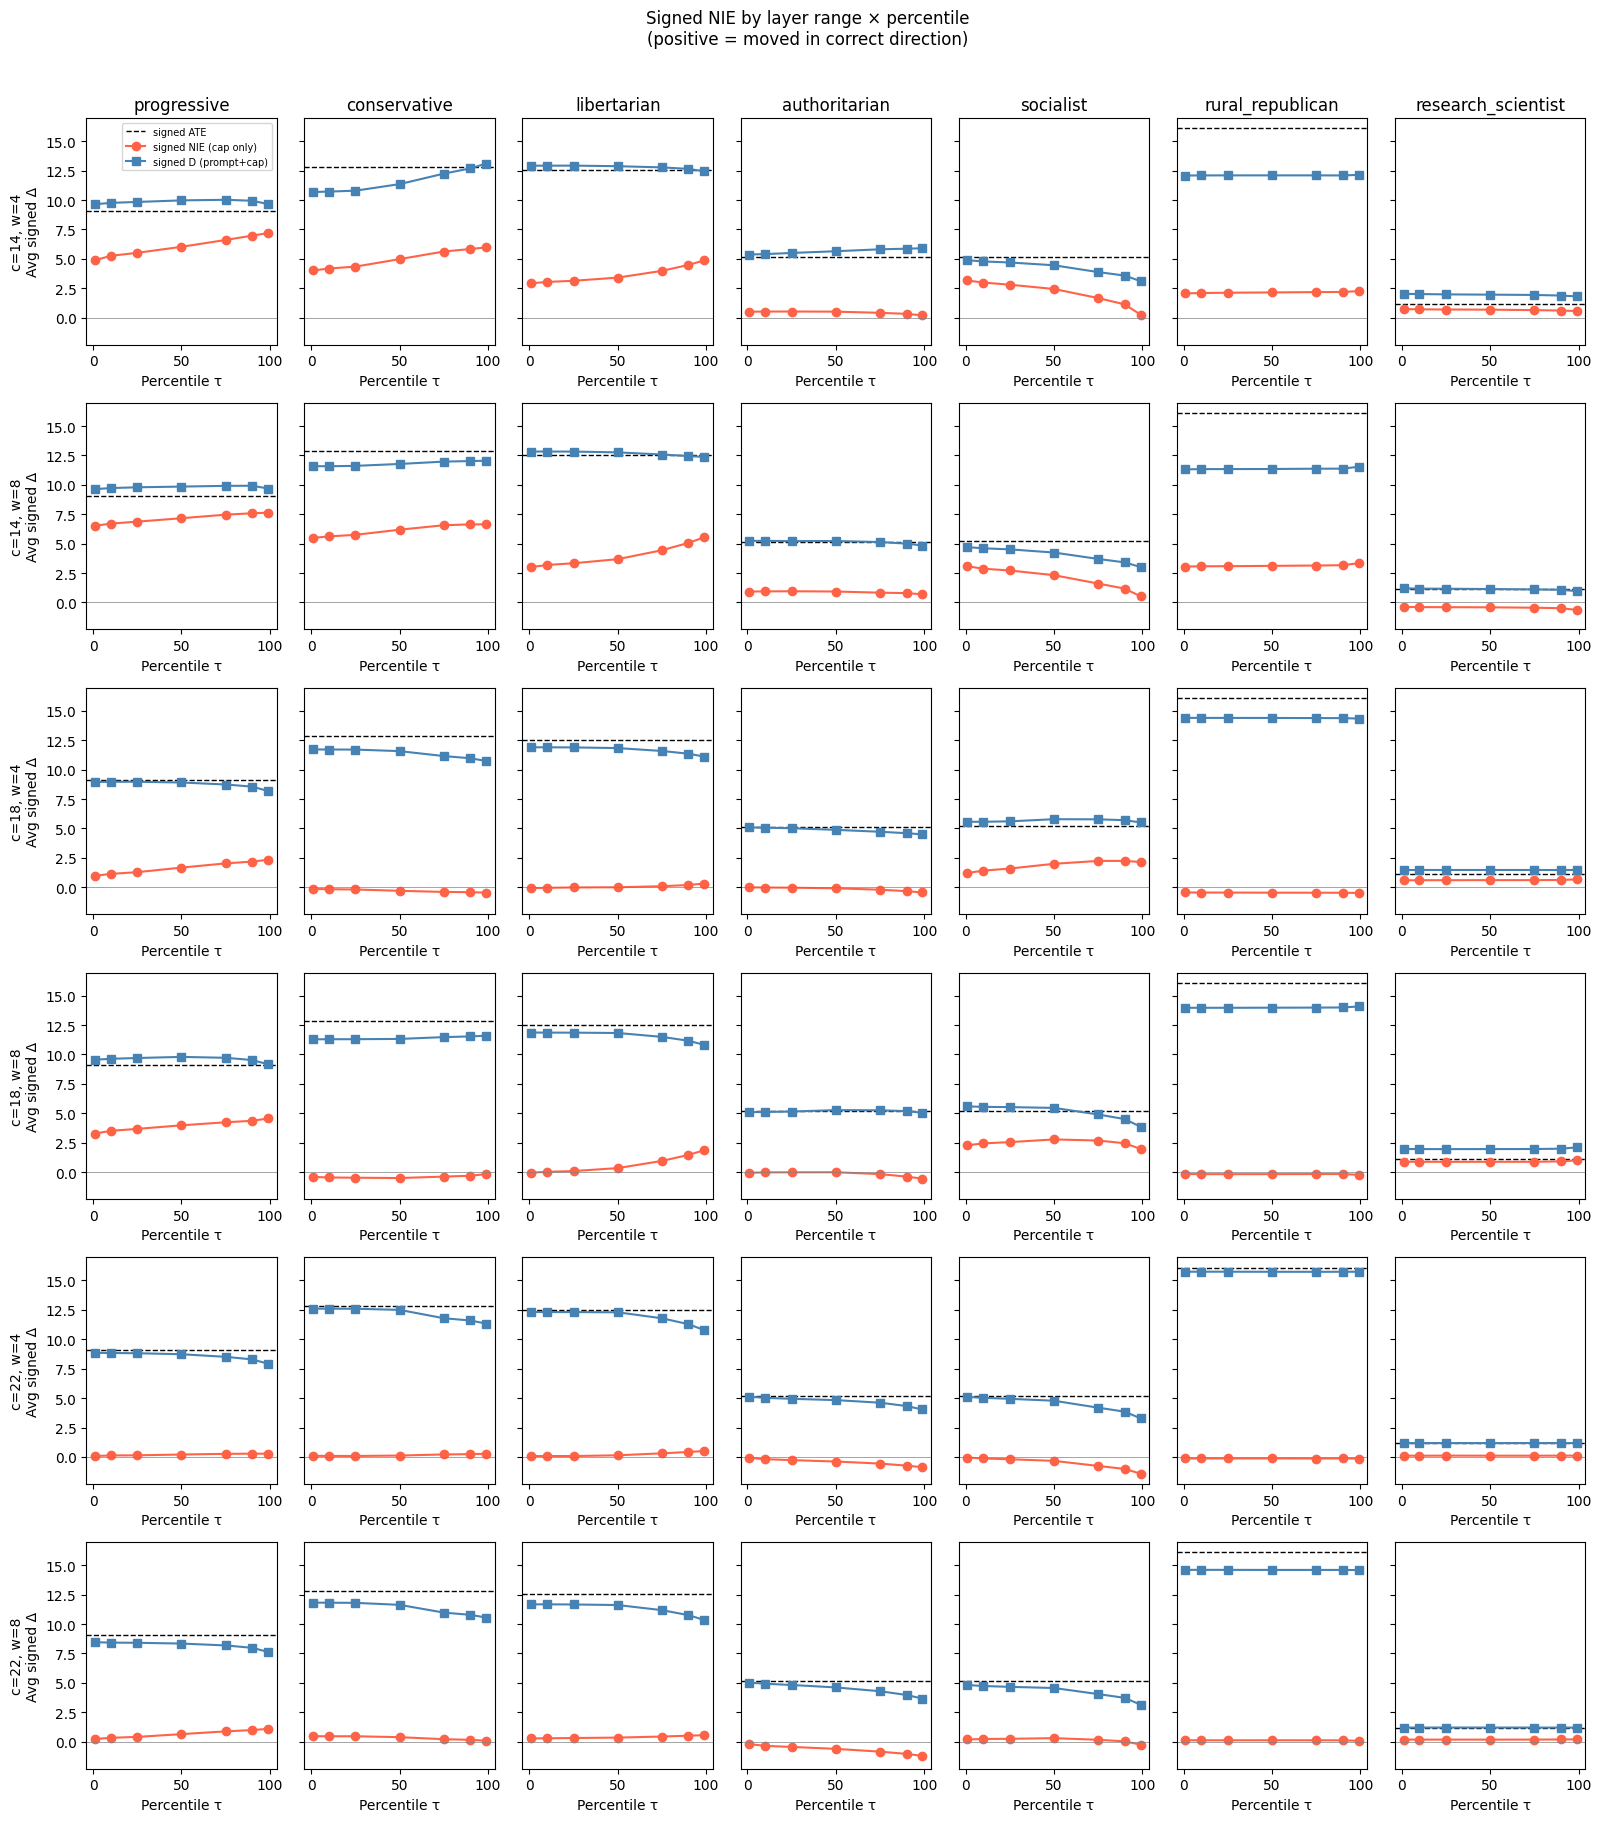

In [ ]:
# Sweep: signed NIE vs percentile, faceted by (center, width)
sweep = df.groupby(['trait', 'center', 'width', 'percentile']).apply(
    lambda g: pd.Series({
        'signed_ATE': g['signed_ATE'].mean(),
        'signed_NIE': g['signed_NIE'].mean(),
        'signed_D':   (g['expected'] * (g['D_prompt_cap'] - g['A_baseline'])).mean(),
    })
).reset_index()

configs = LAYER_CONFIGS
fig, axes = plt.subplots(len(configs), len(non_default),
                         figsize=(16, 3 * len(configs)), sharey=True)

for row_i, (center, width) in enumerate(configs):
    for col_j, trait in enumerate(non_default):
        ax = axes[row_i][col_j]
        sub = sweep[(sweep['trait'] == trait) &
                    (sweep['center'] == center) &
                    (sweep['width'] == width)]

        ax.axhline(sub['signed_ATE'].mean(), color='black', linestyle='--', label='signed ATE', linewidth=1)
        ax.plot(sub['percentile'], sub['signed_NIE'], color='tomato',    marker='o', label='signed NIE (cap only)')
        ax.plot(sub['percentile'], sub['signed_D'],   color='steelblue', marker='s', label='signed D (prompt+cap)')
        ax.axhline(0, color='grey', linewidth=0.5)

        if row_i == 0:
            ax.set_title(trait)
        if col_j == 0:
            ax.set_ylabel(f'c={center}, w={width}\nAvg signed Δ')
        ax.set_xlabel('Percentile τ')
        if row_i == 0 and col_j == 0:
            ax.legend(fontsize=7)

plt.suptitle('Signed NIE by layer range × percentile\n(positive = moved in correct direction)', y=1.01)
plt.tight_layout()
plt.show()


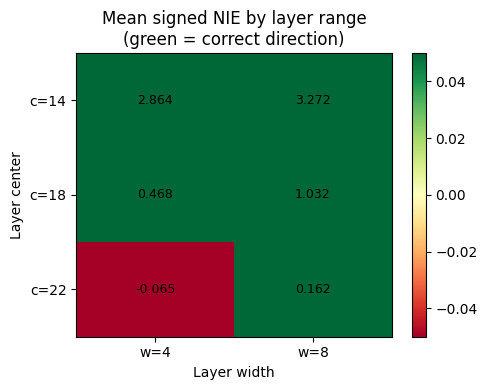

In [ ]:
# Heatmap: mean signed_NIE by (center, width) — which layer range works best?
heatmap_data = df.groupby(['center', 'width'])['signed_NIE'].mean().unstack('width')

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn', vmin=-0.05, vmax=0.05)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([f'w={w}' for w in heatmap_data.columns])
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels([f'c={c}' for c in heatmap_data.index])
ax.set_xlabel('Layer width')
ax.set_ylabel('Layer center')
ax.set_title('Mean signed NIE by layer range\n(green = correct direction)')
plt.colorbar(im, ax=ax)

for i, center in enumerate(heatmap_data.index):
    for j, width in enumerate(heatmap_data.columns):
        val = heatmap_data.loc[center, width]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()


/tmp/ipykernel_2404/1216301096.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dir_acc = df.groupby(['trait', 'center', 'width', 'percentile']).apply(


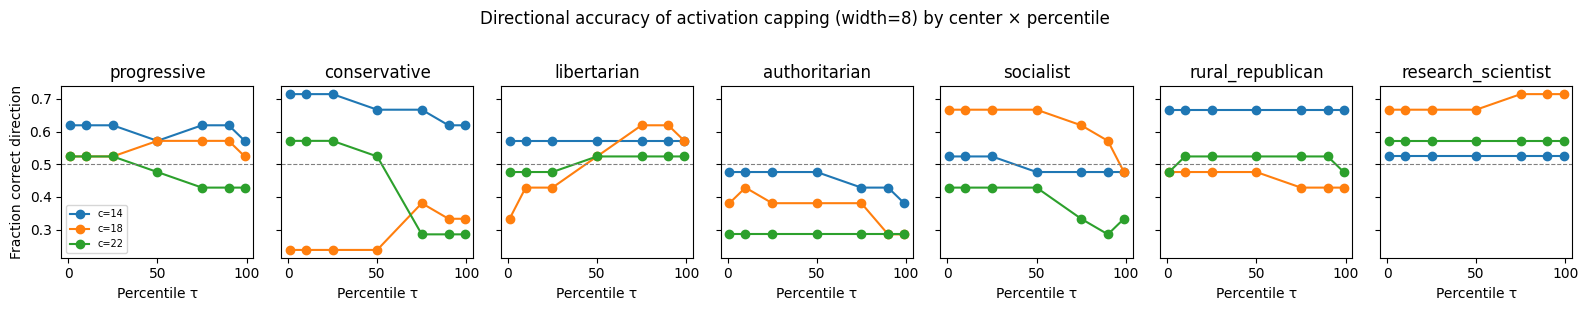

In [ ]:
# Directional accuracy across the percentile and layer-range sweep
dir_acc = df.groupby(['trait', 'center', 'width', 'percentile']).apply(
    lambda g: (g['signed_NIE'] > 0).mean()
).reset_index(name='pct_correct')

# Show accuracy at width=8 (most expressive config) across centers
sub = dir_acc[dir_acc['width'] == 8]
fig, axes = plt.subplots(1, len(non_default), figsize=(16, 3), sharey=True)
for ax, trait in zip(axes, non_default):
    for center in [14, 18, 22]:
        s = sub[(sub['trait'] == trait) & (sub['center'] == center)]
        ax.plot(s['percentile'], s['pct_correct'], marker='o', label=f'c={center}')
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)
    ax.set_title(trait)
    ax.set_xlabel('Percentile τ')
    if ax == axes[0]:
        ax.set_ylabel('Fraction correct direction')
        ax.legend(fontsize=7)
plt.suptitle('Directional accuracy of activation capping (width=8) by center × percentile', y=1.02)
plt.tight_layout()
plt.show()
